# Diabetes Prediction — Kaggle Practice Project

**Dataset attribution:** [Diabetes Data Set](https://www.kaggle.com/datasets/vikasukani/diabetes-data-set) — original dataset author: [vikasukani](https://www.kaggle.com/vikasukani) on Kaggle.

The source dataset remains the property of its author and is subject to Kaggle's terms and any dataset-specific license. This notebook is a learning-oriented adaptation and does not claim ownership of the source dataset.

Local file: `data/diabetes-dataset.csv`

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Loading and Processing from data file

In [2]:
diabetes_data  = pd.read_csv("data/diabetes-dataset.csv")
#在父级文件中阅读用/

diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [3]:
diabetes_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1
1999,2,81,72,15,76,30.1,0.547,25,0


In [4]:
diabetes_data.shape

(2000, 9)

In [5]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


check if there is missing values

In [6]:
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
diabetes_data["Outcome"].value_counts()

Outcome
0    1316
1     684
Name: count, dtype: int64

In [8]:
(diabetes_data == 0).sum()

Pregnancies                  301
Glucose                       13
BloodPressure                 90
SkinThickness                573
Insulin                      956
BMI                           28
DiabetesPedigreeFunction       0
Age                            0
Outcome                     1316
dtype: int64

Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI are considered invalid because these physiological measurements cannot be equal to zero. Therefore, these values are treated as missing data and need to be handled during the data preprocessing stage.

In [9]:
cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

diabetes_data[cols] = diabetes_data[cols].replace(0, np.nan)
diabetes_data[cols].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,138.0,62.0,35.0,NaN,33.6
1,84.0,82.0,31.0,125.0,38.2
2,145.0,NaN,NaN,NaN,44.2
3,135.0,68.0,42.0,250.0,42.3
4,139.0,62.0,41.0,480.0,40.7


In [10]:
diabetes_data.fillna(
    diabetes_data.median(),
    inplace=True
)

EDA

In [11]:
import seaborn as sns
#simpler way to plot
import matplotlib.pyplot as plt

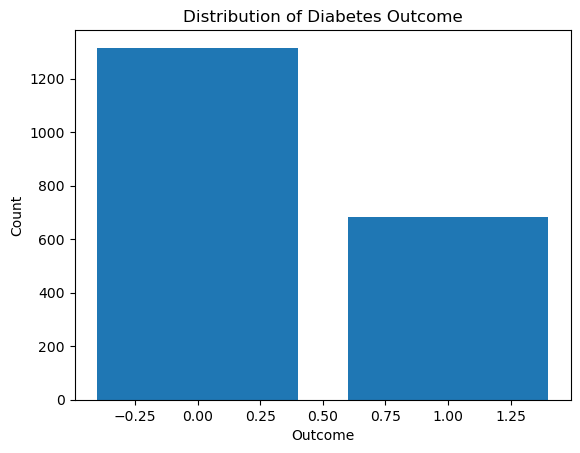

In [12]:
#plot diagram with pure matplot
counts = diabetes_data["Outcome"].value_counts()

plt.bar(
    counts.index,
    counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Outcome")
plt.show()

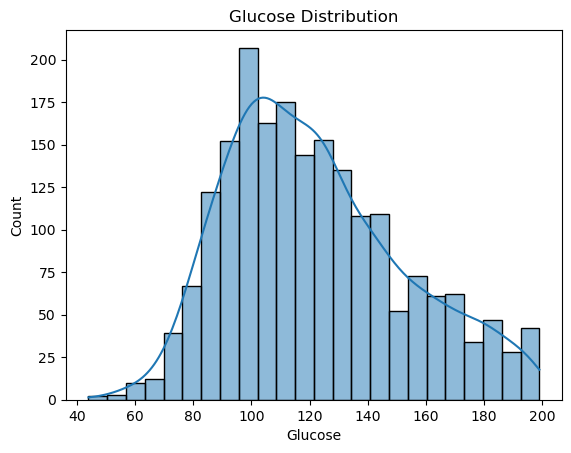

In [13]:
sns.histplot(
    data=diabetes_data,
    x="Glucose",
    kde=True
)

plt.title("Glucose Distribution")
plt.show()

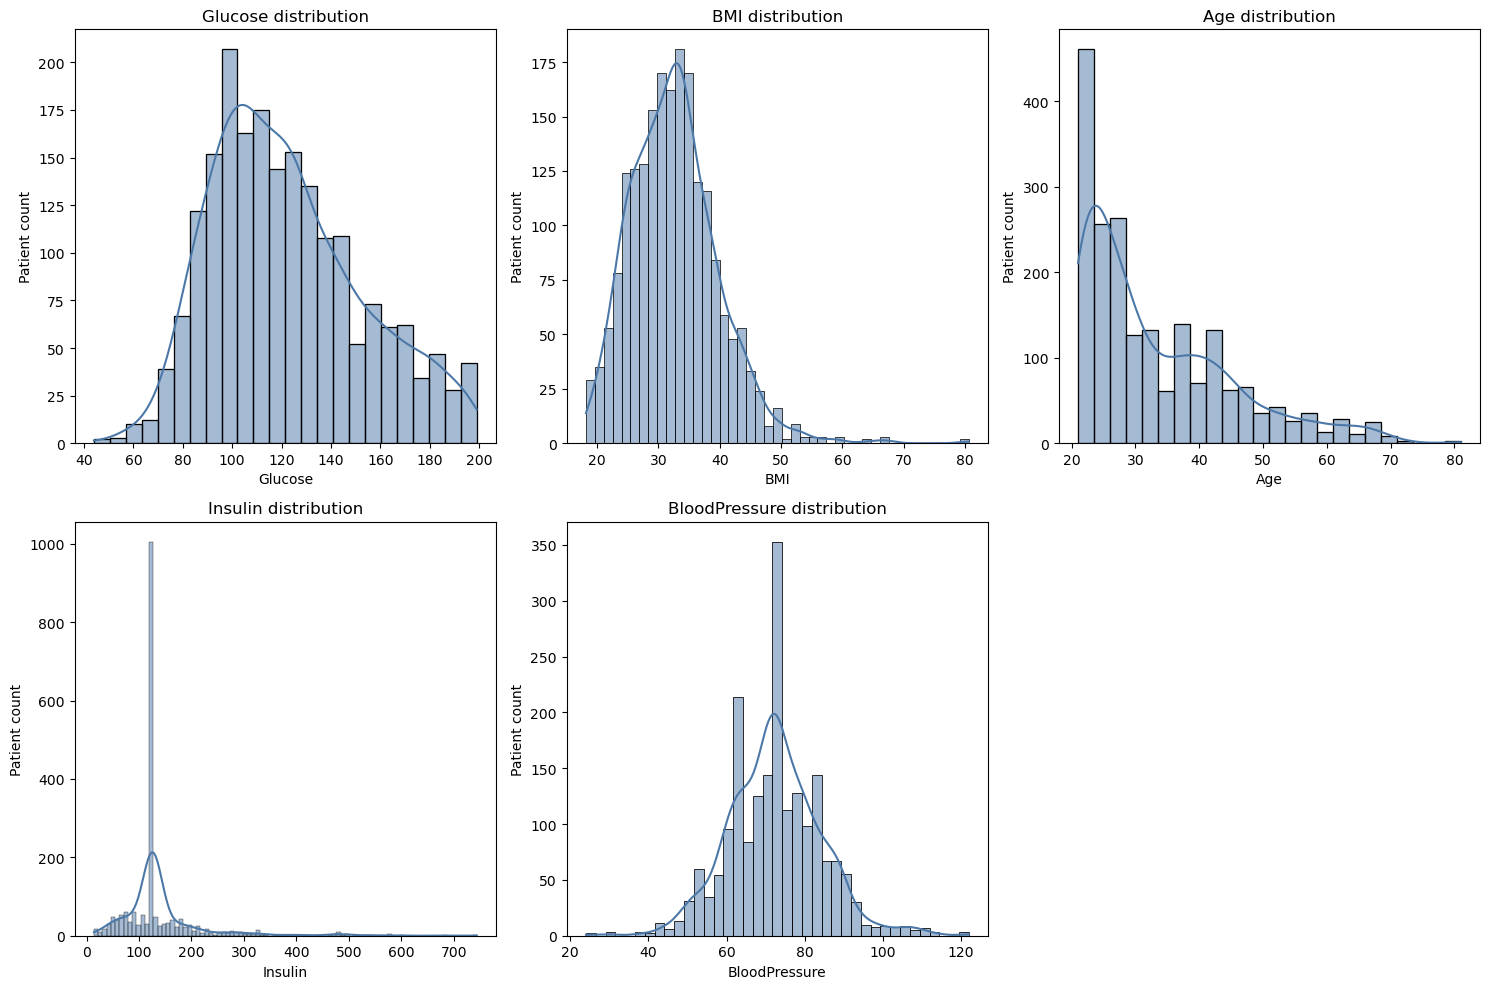

In [14]:
features = [
    "Glucose",
    "BMI",
    "Age",
    "Insulin",
    "BloodPressure"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(
        data=diabetes_data,
        x=feature,
        kde=True,
        color="#4C78A8",
        ax=ax
    )
    ax.set_title(f"{feature} distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Patient count")

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

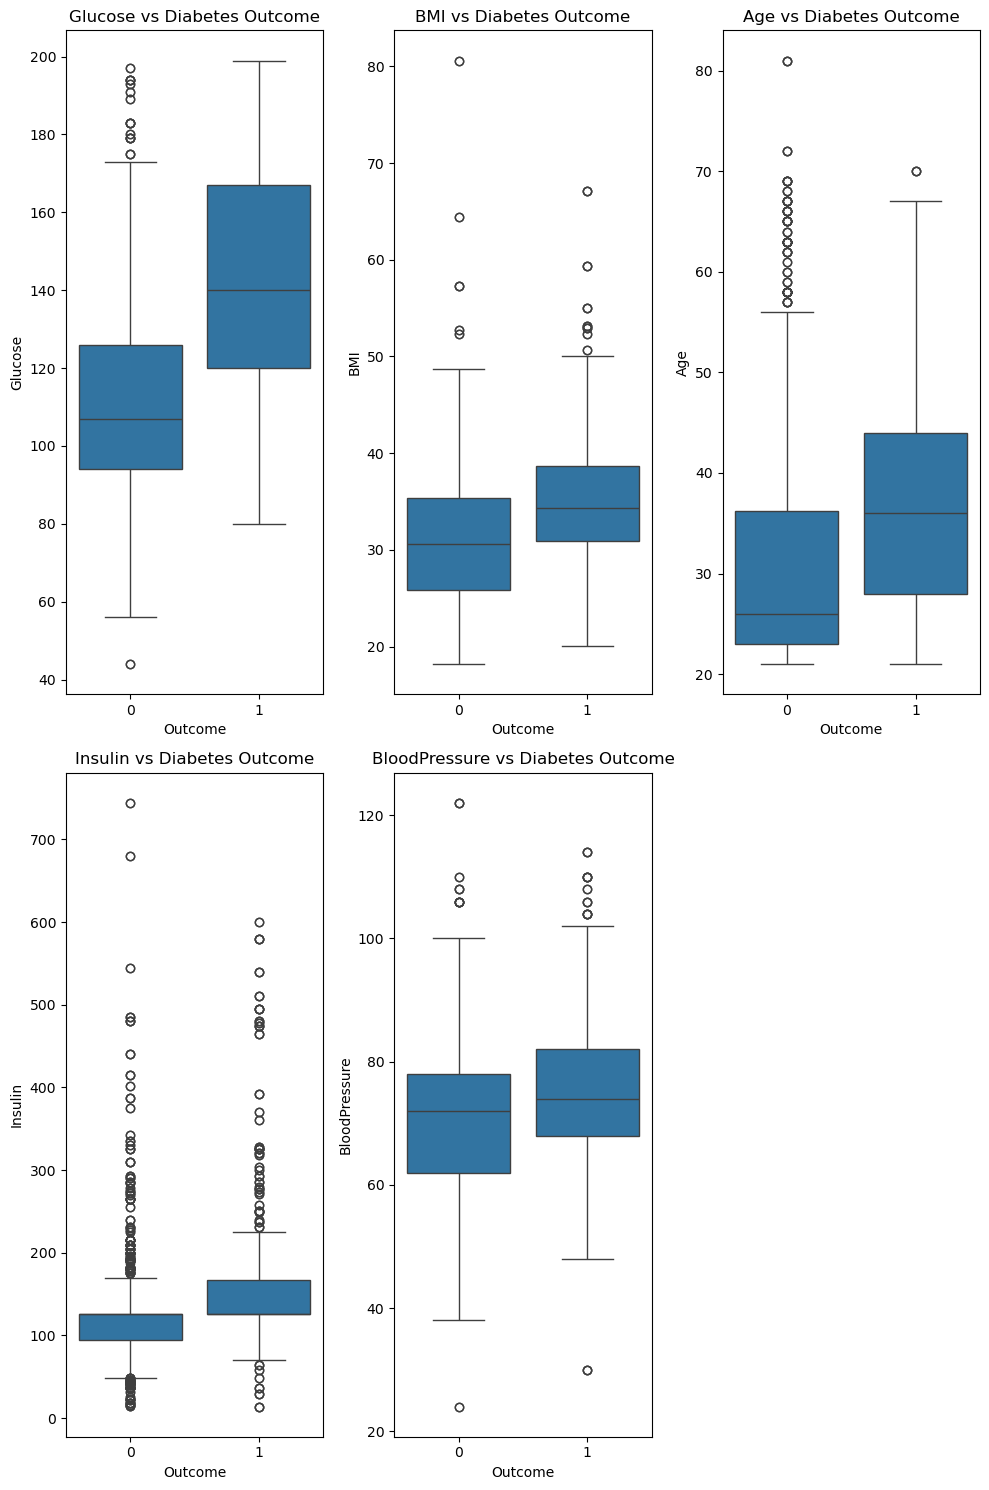

In [15]:
fig, axes = plt.subplots(
    2, 3,
    figsize= (10,15) 
)

axes = axes.flatten()

for ax, feature in zip(axes, features):

    sns.boxplot(
        data=diabetes_data,
        x="Outcome",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} vs Diabetes Outcome")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(feature)

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

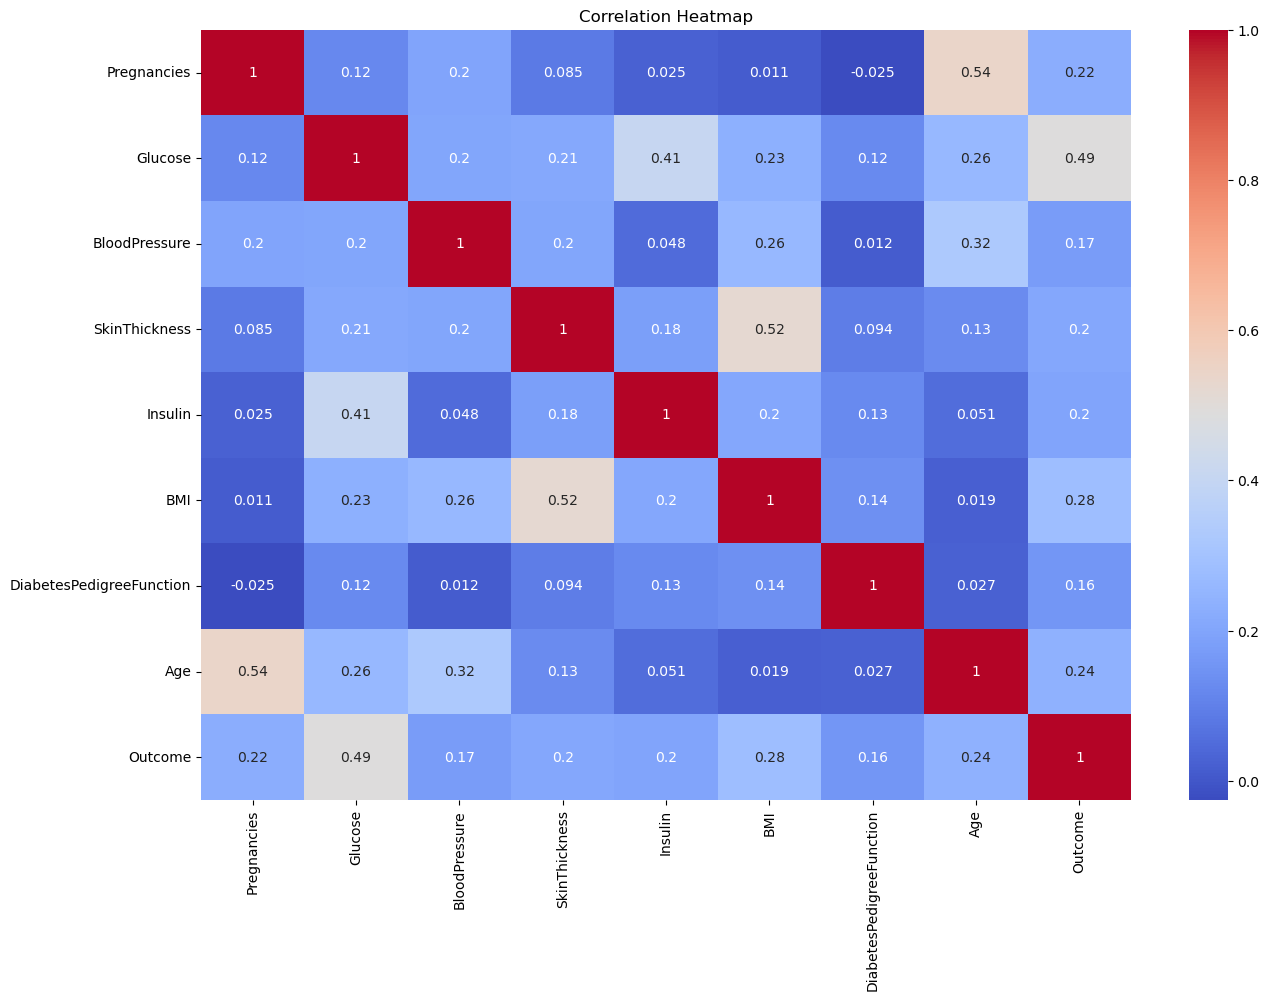

In [16]:
plt.figure(figsize=(15,10))

sns.heatmap(
    diabetes_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


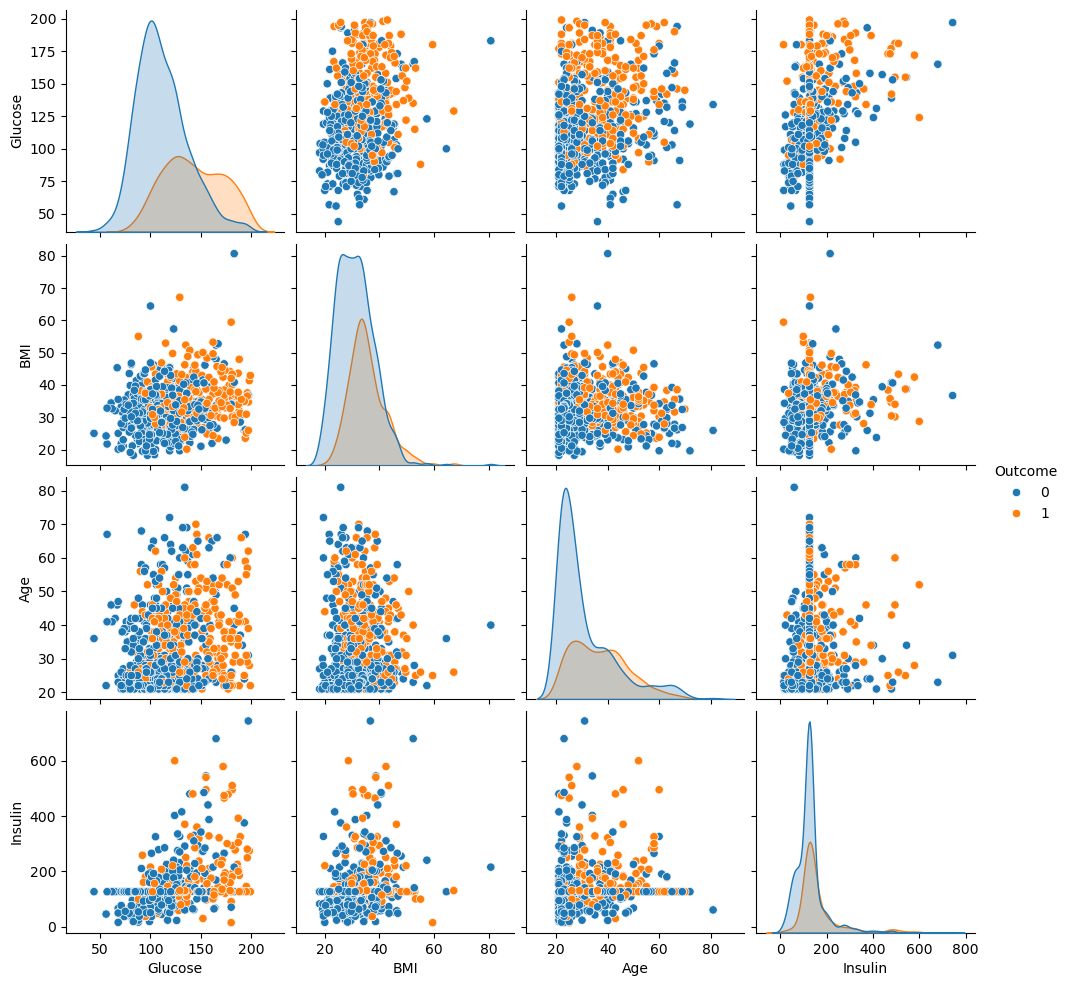

In [17]:
pairplot_columns = ["Glucose", "BMI", "Age", "Insulin", "Outcome"]

sns.pairplot(
    diabetes_data[pairplot_columns],
    hue="Outcome"
)

plt.show()

线（其实是曲线） → KDE（Kernel Density Estimation，核密度估计）曲线，用来表示数据分布

Modelling

In [18]:
X = diabetes_data.drop(columns="Outcome")
Y = diabetes_data["Outcome"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(2000, 8) (1600, 8) (400, 8)


加了 stratify=Y 之后：它会强制"按 Y 的类别比例抽样"——保证训练集和测试集里，有病:没病的比例都跟原始数据的 66:34 基本一致（不是完全随机抽，而是分别在"有病"那一堆里抽 20%、"没病"那一堆里抽 20%，再合并）。这样两次实验之间的结果才可比，不会因为抽样运气不同而忽高忽低。

Solving Scaler Problem  (modified)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression(class_weight='balanced')#加入权重，weight
model.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Model Evaluation

In [21]:
X_train_prediction = model.predict(X_train_scaled)   
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print("Accuracy_score:", training_data_accuracy)

Accuracy_score: 0.743125


In [22]:
X_test_prediction = model.predict(X_test_scaled) 
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy on test data : ', test_data_accuracy)

Accuracy on test data :  0.765


COEF (modified)

In [23]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
#就是把这堆数字和 X 的列名（Glucose、BMI……）一一配对，变成"贴了标签"的数据，方便阅读。
coef_series.sort_values(key=abs, ascending=False)

Glucose                     1.069571
BMI                         0.609413
Pregnancies                 0.434275
DiabetesPedigreeFunction    0.303786
Age                         0.206204
Insulin                    -0.100878
SkinThickness               0.033775
BloodPressure              -0.024336
dtype: float64

Insulin -0.11：这个有意思，是负的，而且排在中间偏后——回忆一下我们之前聊的"共线性"，Insulin 大概率跟 Glucose 本身相关，Glucose 已经把大部分信号"抢走"了，Insulin 剩下能提供的独立信息就很少，方向甚至反了

不收敛问题如何解决的：
新权重 = 旧权重 - 学习步长 × 误差 × 这个特征的原始数值
拿你数据里两个具体的列举例：

Insulin 原始数值大概在 15~846 之间，比如某一行是 500
DiabetesPedigreeFunction 原始数值大概在 0.08~2.42 之间，比如某一行是 0.3
同样的「误差 × 学习步长」，因为 Insulin 后面乘的是 500，DiabetesPedigreeFunction 后面乘的是 0.3，这两个权重每一步挪动的幅度会差出上千倍。

Classification Unbalance Check

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(Y_test, X_test_prediction))
print(classification_report(Y_test, X_test_prediction))
#adding class_weight='balanced'

[[201  62]
 [ 32 105]]
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       263
           1       0.63      0.77      0.69       137

    accuracy                           0.77       400
   macro avg       0.75      0.77      0.75       400
weighted avg       0.78      0.77      0.77       400

